# Lending Club Credit Risk Modeling

This notebook presents an end-to-end approach to building a credit risk model using Lending Club data. The objective is to identify potential defaulters while balancing the trade-off between minimizing credit losses and maintaining customer acceptance.

The workflow covers data preprocessing, feature selection, model training using XGBoost, and performance evaluation through cross-validation. Special emphasis is placed on threshold optimization and cost-based evaluation to align model decisions with business impact rather than relying solely on standard metrics.

The final outcome is a practical and interpretable decision framework for selecting an operating threshold that supports both risk management and business objectives.

### Data Loading

In [45]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, precision_score, recall_score
from xgboost import XGBClassifier
pd.set_option('display.max_columns', None)

c:\lending_club\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [24]:
df = pd.read_csv("lending_club_data.csv")

C:\Users\freddy fernnado\AppData\Local\Temp\ipykernel_2512\1942383514.py:1: DtypeWarning: Columns (0: id, 1: desc, 2: next_pymnt_d, 3: verification_status_joint, 4: sec_app_earliest_cr_line, 5: hardship_type, 6: hardship_reason, 7: hardship_status, 8: hardship_start_date, 9: hardship_end_date, 10: payment_plan_start_date, 11: hardship_loan_status, 12: debt_settlement_flag_date, 13: settlement_status, 14: settlement_date) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("lending_club_data.csv")


### Initial Exploration

In [25]:
df.shape

(2260701, 151)

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Columns: 151 entries, id to settlement_term
dtypes: float64(113), object(1), str(37)
memory usage: 2.5+ GB


In [27]:
df.describe()

,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_amnt,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,annual_inc_joint,dti_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,deferral_term,hardship_amount,hardship_length,hardship_dpd,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,settlement_amount,settlement_percentage,settlement_term
count,0.0,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260664e+06,2.258957e+06,2.260639e+06,2.260668e+06,2.260668e+06,2.260638e+06,1.102166e+06,359156.000000,2.260639e+06,2.260639e+06,2.260668e+06,2.258866e+06,2.260639e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260523e+06,580775.000000,2260668.0,1.207100e+05,120706.000000,2.260639e+06,2.190392e+06,2.190392e+06,1.394538e+06,1.394539e+06,1.394539e+06,1.394539e+06,1.350744e+06,1.394539e+06,1.191818e+06,1.394539e+06,1.394539e+06,1.394539e+06,1.394320e+06,2.190392e+06,1.394539e+06,1.394538e+06,1.394538e+06,2.210638e+06,2.190322e+06,2.185733e+06,2.184597e+06,2.260523e+06,2.260639e+06,2.121597e+06,2.190391e+06,2.190391e+06,2.190392e+06,2.210638e+06,2.187256e+06,519701.000000,1.965233e+06,740359.000000,2.190392e+06,2.190392e+06,2.190392e+06,2.202078e+06,2.190392e+06,2.190392e+06,2.190392e+06,2.190391e+06,2.190392e+06,2.202078e+06,2.107011e+06,2.190392e+06,2.190392e+06,2.190392e+06,2.190237e+06,2.185289e+06,2.259303e+06,2.260563e+06,2.190392e+06,2.210638e+06,2.210638e+06,2.190392e+06,1.080200e+05,108021.000000,108021.000000,108021.000000,108021.000000,108021.000000,106184.000000,108021.000000,108021.000000,108021.000000,108021.000000,35942.000000,10917.0,10917.000000,10917.0,10917.000000,8651.000000,10917.000000,10917.000000,34246.000000,34246.000000,34246.000000
mean,NaN,1.504693e+04,1.504166e+04,1.502344e+04,1.309283e+01,4.458068e+02,7.799243e+04,1.882420e+01,3.068792e-01,6.985882e+02,7.025884e+02,5.768354e-01,3.454092e+01,72.312842,1.161240e+01,1.975278e-01,1.665846e+04,5.033770e+01,2.416255e+01,4.206891e+03,4.205965e+03,1.208256e+04,1.206439e+04,9.505772e+03,2.431388e+03,1.518453e+00,1.438791e+02,2.398257e+01,3.429346e+03,6.876610e+02,6.755397e+02,1.814580e-02,44.164220,1.0,1.236246e+05,19.251817,4.147942e-03,2.327317e+02,1.424922e+05,9.344199e-01,2.779407e+00,6.764314e-01,1.562752e+00,2.122236e+01,3.550665e+04,6.914098e+01,1.290133e+00,2.749923e+00,5.806393e+03,5.703230e+01,3.457394e+04,1.012867e+00,1.47

### Target Definition & Filtering

In [28]:
# Filtering the dataset to include only Fully Paid, Charged Off, and Default to focus on clear loan outcomes and remove ambiguous statuses.
print(f"Value Counts:\n{"="*30}\n{df["loan_status"].value_counts()}")
df = df[df["loan_status"].isin(["Fully Paid", "Charged Off", "Default"])]
df['target'] = df['loan_status'].map({
    'Fully Paid': 0,
    'Charged Off': 1,
    'Default': 1
})
print(f"{'='*30}\nDataset Shape after filtering: {df.shape}")

Value Counts:
loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64
Dataset Shape after filtering: (1345350, 152)


C:\Users\freddy fernnado\AppData\Local\Temp\ipykernel_2512\1389554276.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['target'] = df['loan_status'].map({


### Missing Values Analysis & Cleaning

In [29]:
# % of NaN per column
na_ratio = df.isna().mean().sort_values(ascending=False)
na_ratio.head(20)

member_id                                     1.000000
next_pymnt_d                                  0.999970
orig_projected_additional_accrued_interest    0.997204
hardship_amount                               0.995722
hardship_last_payment_amount                  0.995722
hardship_length                               0.995722
hardship_status                               0.995722
hardship_reason                               0.995722
deferral_term                                 0.995722
hardship_start_date                           0.995722
hardship_end_date                             0.995722
hardship_type                                 0.995722
hardship_loan_status                          0.995722
hardship_payoff_balance_amount                0.995722
hardship_dpd                                  0.995722
payment_plan_start_date                       0.995722
sec_app_mths_since_last_major_derog           0.995058
sec_app_revol_util                            0.986392
revol_bal_

### Feature Cleaning (Noise & Leakage Removal)

In [30]:
# Drop IDs/text, high-missing columns, and post-outcome leakage variables
drop_cols = [
    'member_id', 'emp_title', 'url', 'title', 'loan_status'
    ,'pymnt_plan','hardship_flag','debt_settlement_flag'
    ,'dibursment_method','policy_code','application_type'
    ,'dibursement_method','zip_code','addr_state'
    ,'disbursement_method'
    ]

leakage = [
    'out_prncp', 'out_prncp_inv'
    ,'last_pymnt_d','last_credit_pull_d'
    ,'issue_d'
    ,'id','total_pymnt', 'total_pymnt_inv'
    ,'total_rec_prncp', 'total_rec_int'
    ,'total_rec_late_fee', 'recoveries'
    ,'collection_recovery_fee'
    ,'last_pymnt_amnt'
    ,'last_fico_range_high', 'last_fico_range_low'
]

# Dropping grade/sub_grade: Lending Club internal risk scores built from borrower features.
# Keeping them would introduce redundancy and bias the model toward LC's scoring logic.
lc_scores = ['grade', 'sub_grade']

# Remove columns with excessive missing values
df = df.loc[:, df.isna().mean() < 0.3]

# Drop predefined irrelevant and leakage columns
df = df.drop(columns=[c for c in (drop_cols + leakage + lc_scores) if c in df.columns])

In [31]:
df.shape

(1345350, 64)

### Handling categorical features

In [32]:
# Handling categorical features:
# Convert structured strings to numeric (term, emp_length, credit history)
# Group noisy/self-reported categories (purpose, home_ownership)
# Keep transformations simple and model-friendly for XGBoost

# --- TERM (ordinal) ---
df["verification_status"] = df["verification_status"].map({
    'Not Verified': 0,
    'Verified': 1,
    'Source Verified': 1
})

# --- TERM ---
# 0 = short term(36 months), 1 = long term 60 months)
df["term"] = df["term"].map({' 36 months': 0, ' 60 months': 1})

# --- EMPLOYMENT LENGTH (ordinal) ---
# 0 = <1 year ... 10 = 10+ years
emp_map = {
    '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3,
    '4 years': 4, '5 years': 5, '6 years': 6, '7 years': 7,
    '8 years': 8, '9 years': 9, '10+ years': 10
}
df["emp_length"] = df["emp_length"].map(emp_map)

# --- HOME OWNERSHIP ---
# 0 = RENT, 1 = OWN, 2 = MORTGAGE
df["home_ownership"] = df["home_ownership"].replace({
    'ANY': 'OTHER', 'NONE': 'OTHER'
})

df = df[df["home_ownership"] != "OTHER"]  # filtra antes

home_map = {
    'RENT': 0,
    'OWN': 1,
    'MORTGAGE': 2
}
df["home_ownership"] = df["home_ownership"].map(home_map)
# Dropping other as is unstable and the number of cases are small compared to the entire dataset
df = df[df["home_ownership"] != "OTHER"]

# --- PURPOSE (grouped risk levels) ---
# 0 = low risk, 1 = mid risk, 2 = high risk
purpose_map = {
    'debt_consolidation': 0, 'credit_card': 0, 'home_improvement': 0,
    'major_purchase': 1, 'car': 1, 'medical': 1, 'moving': 1,
    'wedding': 1, 'house': 1, 'educational': 1, 'renewable_energy': 1,
    'small_business': 2, 'vacation': 2, 'other': 2
}
df["purpose"] = df["purpose"].map(purpose_map)

# --- EARLIEST CREDIT LINE → CREDIT AGE ---
# Numeric feature: years since first credit line
df["earliest_cr_line"] = pd.to_datetime(df["earliest_cr_line"])
df["credit_age"] = (pd.Timestamp('today') - df["earliest_cr_line"]).dt.days // 365
df = df.drop(columns=["earliest_cr_line"])

# --- INITIAL LIST STATUS ---
# 0 = f (fractional), 1 = w (whole loan)
df["initial_list_status"] = df["initial_list_status"].map({'f': 0, 'w': 1})

C:\Users\freddy fernnado\AppData\Local\Temp\ipykernel_2512\1799043794.py:55: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["earliest_cr_line"] = pd.to_datetime(df["earliest_cr_line"])


### Remove Highly Correlated (Redundant) Features

In [33]:
# Identify highly correlated features to detect redundancy.
corr_matrix = df.corr(numeric_only=True)

threshold = 0.6

corr_pairs = (
    corr_matrix.abs()
    .unstack()
    .reset_index()
)
corr_pairs.columns = ["feature_1", "feature_2", "correlation"]

# Drop self and duplicates
corr_pairs = corr_pairs[corr_pairs["feature_1"] != corr_pairs["feature_2"]]
corr_pairs["pair"] = corr_pairs.apply(
    lambda x: tuple(sorted([x["feature_1"], x["feature_2"]])), axis=1
)
corr_pairs = corr_pairs.drop_duplicates("pair")

# Filter
high_corr = corr_pairs[corr_pairs["correlation"] > threshold]

high_corr.sort_values(by="correlation", ascending=False).head()

,feature_1,feature_2,correlation,pair
846,fico_range_low,fico_range_high,1.000000,"(fico_range_high, fico_range_low)"
1,loan_amnt,funded_amnt,0.999564,"(funded_amnt, loan_amnt)"
66,funded_amnt,funded_amnt_inv,0.999105,"(funded_amnt, funded_amnt_inv)"
1073,open_acc,num_sats,0.998728,"(num_sats, open_acc)"
2,loan_amnt,funded_amnt_inv,0.998581,"(funded_amnt_inv, loan_amnt)"


In [34]:
# Remove redundant features based on correlation + domain knowledge.
# For each highly correlated group, we keep one representative feature
# and drop the rest to improve model interpretability and stability.

# --- FICO → combine ---
df["fico"] = (df["fico_range_low"] + df["fico_range_high"]) / 2
df = df.drop(columns=["fico_range_low", "fico_range_high"])

# --- Loan amounts → keep loan_amnt ---
df = df.drop(columns=["funded_amnt", "funded_amnt_inv"])

# --- Account counts → reduce redundancy ---
drop_accounts = [
    "num_sats", "num_op_rev_tl", "num_rev_accts"
]
df = df.drop(columns=[c for c in drop_accounts if c in df.columns])

# --- Revolving / utilization → keep ratios ---
drop_revol = [
    "revol_bal", "total_rev_hi_lim", "percent_bc_gt_75"
]
df = df.drop(columns=[c for c in drop_revol if c in df.columns])

# --- Balance features → keep avg_cur_bal ---
df = df.drop(columns=["tot_cur_bal", "tot_hi_cred_lim"])

# --- Credit limits → keep bc_open_to_buy ---
df = df.drop(columns=["total_bc_limit"])

# --- Delinquency → keep num_tl_90g_dpd_24m ---
df = df.drop(columns=["delinq_2yrs"])

# --- Time features → keep credit_age ---
df = df.drop(columns=["mo_sin_old_rev_tl_op"])

# --- Public records → simplify ---
df = df.drop(columns=["pub_rec"])

### Feature Selection

In [35]:
X = df.drop(columns=['target'])
y = df['target']

In [36]:
obj_col = X.select_dtypes(include=['object'])

In [37]:
# Train a quick baseline model to identify the most important features
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=0
)
model.fit(X, y)

importances = pd.Series(model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(15)

top_features

int_rate                0.217033
term                    0.182211
fico                    0.062885
verification_status     0.053056
mort_acc                0.032823
home_ownership          0.031437
avg_cur_bal             0.027620
num_tl_op_past_12m      0.026383
dti                     0.026008
acc_open_past_24mths    0.025178
initial_list_status     0.020096
emp_length              0.017182
num_tl_120dpd_2m        0.014941
installment             0.014720
loan_amnt               0.013600
dtype: float32

#### Test impact of suspicious features (initial_list_status)

In [38]:
# --- Baseline dataset ---
X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict_proba(X_test)[:, 1]

baseline_auc = roc_auc_score(y_test, y_pred)
print("Baseline AUC:", baseline_auc)

Baseline AUC: 0.7296142862516122


#### Drop initial_list_status and compare

In [39]:
# --- Remove suspicious feature ---
X_no_init = X.drop(columns=["initial_list_status"])

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_no_init, y, test_size=0.2, random_state=42
)

model2 = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model2.fit(X_train2, y_train2)
y_pred2 = model2.predict_proba(X_test2)[:, 1]

test_auc = roc_auc_score(y_test2, y_pred2)
print("AUC without initial_list_status:", test_auc)

AUC without initial_list_status: 0.729501769440996


### Drop initial_list_status and installment

In [40]:
# Dropping initial_list_status: no meaningful impact on model performance (AUC unchanged).
# Likely captures operational/servicing information rather than borrower risk.
# Dropping installment. Installment is a function of loan_amnt, term, and int_rate
df = df.drop(columns=["initial_list_status", "installment"])

### Feature Selection Validation

In [41]:
top_feature_names = [
    col for col in top_features.index 
    if col in df.columns
]
# Full model
X_full = df.drop(columns=["target"])
y = df["target"]

# Reduced model
X_reduced = df[top_feature_names]

X_train_f, X_test_f, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, random_state=0
)

X_train_r, X_test_r, _, _ = train_test_split(
    X_reduced, y, test_size=0.2, random_state=0
)

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=0
)

# Full
model.fit(X_train_f, y_train)
auc_full = roc_auc_score(y_test, model.predict_proba(X_test_f)[:,1])

# Reduced
model.fit(X_train_r, y_train)
auc_reduced = roc_auc_score(y_test, model.predict_proba(X_test_r)[:,1])

print("Full AUC:", auc_full)
print("Reduced AUC:", auc_reduced)

Full AUC: 0.7286381266982228
Reduced AUC: 0.720022450677919


The selected features are retained because they capture complementary aspects of credit risk,
with minimal redundancy after correlation filtering and importance-based selection.

- int_rate: Strong proxy for perceived borrower risk by the lender.
- term: Longer terms are typically associated with higher default probability.
- fico: Core indicator of borrower creditworthiness.
- verification_status: Reflects reliability of reported income.
- mort_acc: Indicates experience with mortgage obligations (credit maturity).
- home_ownership: Captures financial stability and asset backing.
- avg_cur_bal: Represents overall financial burden across accounts.
- dti: Measures repayment capacity relative to income.
- acc_open_past_24mths: Recent credit activity, proxy for credit demand.
- num_tl_op_past_12m: Short-term credit behavior and potential risk-seeking.
- emp_length: Stability of income source.
- num_tl_120dpd_2m: Severe delinquency signal (high-risk behavior).
- loan_amnt: Exposure size, relevant for risk scaling.

Together, these features provide a balanced view across:
creditworthiness, behavior, capacity, stability, and loan characteristics,
while maintaining model simplicity and interpretability.

### Robust Model Validation

In this section, we evaluate the stability and reliability of the model
using cross-validation, ensuring that performance is consistent across
different data splits and not driven by a single train-test partition.

In [42]:
X = df[top_feature_names]
y = df["target"]
skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=0)

auc_scores = []
precision_scores = []
recall_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    # Model (keep it simple first)
    model = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=0,
        eval_metric="logloss"
    )
    
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred_proba = model.predict_proba(X_val)[:, 1]
    y_pred = (y_pred_proba >= 0.5).astype(int)
    
    # Metrics
    auc = roc_auc_score(y_val, y_pred_proba)
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    
    auc_scores.append(auc)
    precision_scores.append(precision)
    recall_scores.append(recall)
    
    print(f"Fold {fold+1} → AUC: {auc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}")

# Summary
print("\n--- Cross-Validation Results ---")
print(f"AUC: {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")
print(f"Precision: {np.mean(precision_scores):.4f}")
print(f"Recall: {np.mean(recall_scores):.4f}")

Fold 1 → AUC: 0.7177, Precision: 0.5650, Recall: 0.0743
Fold 2 → AUC: 0.7179, Precision: 0.5657, Recall: 0.0769
Fold 3 → AUC: 0.7180, Precision: 0.5624, Recall: 0.0764
Fold 4 → AUC: 0.7173, Precision: 0.5607, Recall: 0.0760

--- Cross-Validation Results ---
AUC: 0.7177 ± 0.0003
Precision: 0.5635
Recall: 0.0759


### Model Explainability (SHAP)

In this section, we analyze how the model makes decisions using SHAP values,
identifying the most influential features and verifying that their impact
aligns with domain expectations.

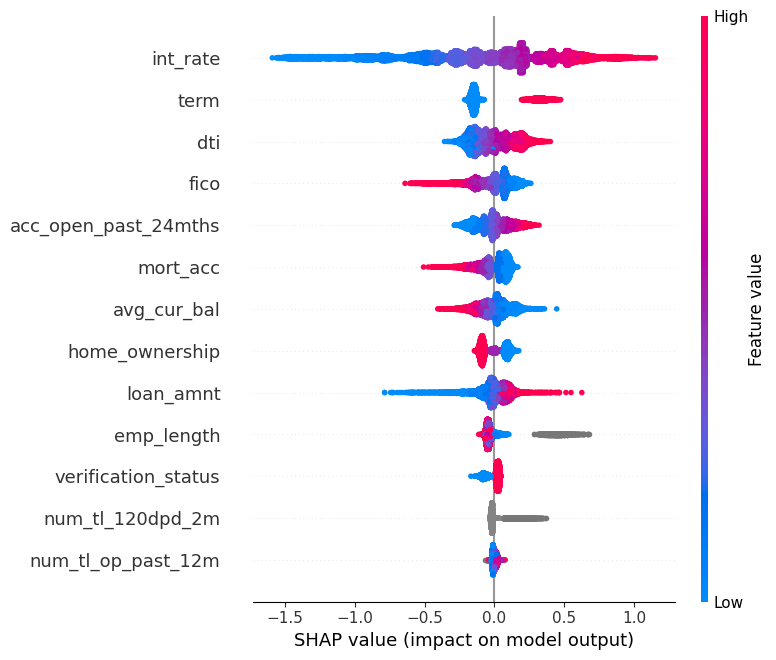

In [48]:
# Sample the data (important)
X_sample = X.sample(10000, random_state=0)

# Explainer
explainer = shap.Explainer(model)

# Compute SHAP on sample only
shap_values = explainer(X_sample)

# Plot
shap.summary_plot(shap_values, X_sample)

### Feature Dependency Stress Test (int_rate)

Based on SHAP results, 'int_rate' shows a dominant impact on model predictions.
This raises the question of whether the model is overly dependent on this feature.

In this section, we perform a stress test by removing 'int_rate' and retraining
the model to evaluate how much performance degrades.

A significant drop in AUC would indicate strong dependency, while a small drop
would suggest that other features also capture meaningful risk signals.

In [63]:
# Remove int_rate
X_no_int = X.drop(columns=["int_rate"])

# Cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

auc_scores_no_int = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_no_int, y)):
    X_train, X_val = X_no_int.iloc[train_idx], X_no_int.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=0,
        eval_metric="logloss"
    )
    
    model.fit(X_train, y_train)
    
    y_pred_proba = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred_proba)
    
    auc_scores_no_int.append(auc)
    print(f"Fold {fold+1} → AUC (no int_rate): {auc:.4f}")

# Summary
print("\n--- Stress Test Results (without int_rate) ---")
print(f"AUC: {np.mean(auc_scores_no_int):.4f} ± {np.std(auc_scores_no_int):.4f}")

Fold 1 → AUC (no int_rate): 0.6975
Fold 2 → AUC (no int_rate): 0.6973
Fold 3 → AUC (no int_rate): 0.6986
Fold 4 → AUC (no int_rate): 0.6967
Fold 5 → AUC (no int_rate): 0.6978

--- Stress Test Results (without int_rate) ---
AUC: 0.6976 ± 0.0006


We will keep int_rate, because it captures the lender’s aggregated risk assessment,
providing strong predictive signal while the model still maintains performance without it,
indicating it enhances rather than dominates the overall prediction.

### Threshold Tuning and Decision Trade-off

The model currently uses a default threshold of 0.5, which results in very low recall.
In this section, we evaluate how different probability thresholds impact
precision and recall to identify a more suitable decision boundary
for detecting defaults while controlling false positives.

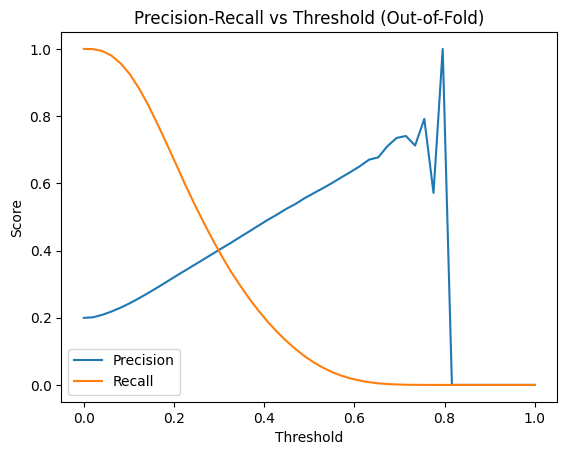

In [65]:
y_true_all = []
y_proba_all = []

# Generate out-of-fold predictions
for train_idx, val_idx in skf.split(X, y):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=0,
        eval_metric="logloss"
    )
    
    model.fit(X_train, y_train)
    
    y_proba = model.predict_proba(X_val)[:, 1]
    
    y_true_all.extend(y_val)
    y_proba_all.extend(y_proba)

# Convert to arrays
y_true_all = np.array(y_true_all)
y_proba_all = np.array(y_proba_all)

# Threshold analysis
thresholds = np.linspace(0.0, 1.0, 50)

precisions = []
recalls = []

for t in thresholds:
    y_pred = (y_proba_all >= t).astype(int)
    
    precision = precision_score(y_true_all, y_pred, zero_division=0)
    recall = recall_score(y_true_all, y_pred)
    
    precisions.append(precision)
    recalls.append(recall)

# Plot
plt.figure()
plt.plot(thresholds, precisions, label="Precision")
plt.plot(thresholds, recalls, label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall vs Threshold (Out-of-Fold)")
plt.legend()
plt.show()

Threshold = 0.3 chosen to increase recall (catch more defaulters), while keeping precision at an acceptable level to limit false positives

### Final Model Evaluation (Selected Threshold)

In [69]:
t = 0.30

# Final predictions using chosen threshold
y_pred_final = (y_proba_all >= t).astype(int)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# Metrics
print("AUC:", roc_auc_score(y_true_all, y_proba_all))
print("\nConfusion Matrix:")
print(confusion_matrix(y_true_all, y_pred_final))

print("\nClassification Report:")
print(classification_report(y_true_all, y_pred_final))

AUC: 0.7177045941909959

Confusion Matrix:
[[917409 158954]
 [161737 106772]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85   1076363
           1       0.40      0.40      0.40    268509

    accuracy                           0.76   1344872
   macro avg       0.63      0.62      0.63   1344872
weighted avg       0.76      0.76      0.76   1344872



In [67]:
t = 0.35

# Final predictions using chosen threshold
y_pred_final = (y_proba_all >= t).astype(int)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# Metrics
print("AUC:", roc_auc_score(y_true_all, y_proba_all))
print("\nConfusion Matrix:")
print(confusion_matrix(y_true_all, y_pred_final))

print("\nClassification Report:")
print(classification_report(y_true_all, y_pred_final))

AUC: 0.7177045941909959

Confusion Matrix:
[[978700  97663]
 [190759  77750]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87   1076363
           1       0.44      0.29      0.35    268509

    accuracy                           0.79   1344872
   macro avg       0.64      0.60      0.61   1344872
weighted avg       0.76      0.79      0.77   1344872



### Cost-based evaluation

In [73]:
# --- Business profit function ---
def profit(tp, fp, fn, tn):
    gain_tp = 1000   # avoid lending to a defaulter
    cost_fp = -800   # reject a good customer
    cost_fn = -1000  # lend to a defaulter
    gain_tn = 0

    return tp*gain_tp + fp*cost_fp + fn*cost_fn + tn*gain_tn


# --- Evaluate a single threshold ---
def evaluate_threshold(y_true, y_proba, t):
    # Convert probabilities to predictions
    y_pred = (y_proba >= t).astype(int)
    
    # Confusion matrix: [[tn, fp], [fn, tp]]
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    # Compute profit
    p = profit(tp, fp, fn, tn)
    
    return {
        "threshold": t,
        "tn": tn, "fp": fp, "fn": fn, "tp": tp,
        "profit": p
    }


# --- Evaluate specific thresholds (0.3 and 0.35) ---
results_03 = evaluate_threshold(y_true_all, y_proba_all, 0.3)
results_035 = evaluate_threshold(y_true_all, y_proba_all, 0.35)

print("Threshold 0.3 → Profit:", results_03["profit"])
print("Threshold 0.35 → Profit:", results_035["profit"])


# --- (Optional) Find best threshold automatically ---
thresholds = np.linspace(0.01, 0.8, 100)
all_results = [evaluate_threshold(y_true_all, y_proba_all, t) for t in thresholds]

best_result = max(all_results, key=lambda x: x["profit"])

print("\nBest Threshold:", best_result["threshold"])
print("Best Profit:", best_result["profit"])

Threshold 0.3 → Profit: -182128200
Threshold 0.35 → Profit: -191139400

Best Threshold: 0.28131313131313135
Best Profit: -181606600


**Business context**

We define a simple profit function to approximate business impact:
- Missing a defaulter (FN) is very costly
- Rejecting a good customer (FP) also has a significant cost

This allows us to select a threshold that maximizes expected profit,
instead of relying only on metrics like precision or recall.

However, this approach depends heavily on the chosen cost assumptions.
A threshold that maximizes profit numerically may lead to rejecting too many
good customers or harming growth.

Therefore, the final threshold should not be decided purely by this function.
It must be validated with business stakeholders, balancing risk reduction
and customer acceptance.